In [105]:
import pandas as pd
import numpy as np

In [106]:
df  = pd.read_csv('Fish.csv')
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [107]:
df['Species'].unique()

array(['Bream', 'Roach', 'Whitefish', 'Parkki', 'Perch', 'Pike', 'Smelt'],
      dtype=object)

In [108]:
df.isna().sum()

Species    0
Weight     0
Length1    0
Length2    0
Length3    0
Height     0
Width      0
dtype: int64

In [111]:
df = df.drop('Species',axis=1)

In [6]:
x = df[['Length1']]
y = df[['Weight']]


In [7]:
x

,Length1
0,23.2
1,24.0
2,23.9
3,26.3
4,26.5
...,...
154,11.5
155,11.7
156,12.1
157,13.2


In [8]:
y

,Weight
0,242.0
1,290.0
2,340.0
3,363.0
4,430.0
...,...
154,12.2
155,13.4
156,12.2
157,19.7


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

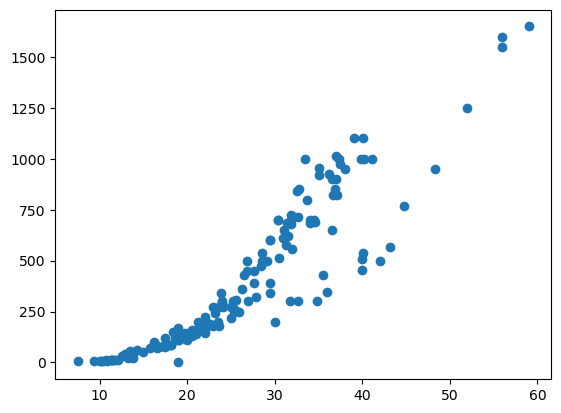

In [10]:
plt.scatter(x,y)

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=10)

In [13]:
print(x_test.shape,x_train.shape,y_test.shape,y_train.shape)

(32, 1) (127, 1) (32, 1) (127, 1)


# LinearRegression

In [14]:
from sklearn.linear_model import LinearRegression  # importing LineraRegression

In [15]:
model = LinearRegression()    # Model Creation

In [16]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
y_pred = model.predict(x_test)

In [18]:
y_pred

array([[ -35.804181  ],
       [ 177.06733726],
       [ 236.93745177],
       [ 596.15813884],
       [ 589.50590389],
       [ 250.24192167],
       [ 532.96190686],
       [ 479.74402729],
       [ 483.07014476],
       [ 379.96050311],
       [ 240.26356925],
       [  77.28381308],
       [ 153.78451495],
       [ 576.201434  ],
       [ 140.48004506],
       [ -89.02206056],
       [ 366.65603321],
       [ 333.39485849],
       [ 167.08898484],
       [ 300.13368376],
       [ 566.22308158],
       [ 266.87250903],
       [ -25.82582858],
       [ 373.30826816],
       [ 579.52755148],
       [ 213.65462946],
       [ 167.08898484],
       [ 336.72097596],
       [ 865.57365414],
       [-128.93547024],
       [ 200.35015957],
       [ 300.13368376]])

In [19]:
model.coef_

array([[33.26117473]])

In [20]:
model.intercept_

array([-464.87333499])

In [21]:
pd.DataFrame({
    'actual_data':y_test.squeeze(),
    'predicted_data':y_pred.squeeze()
})

,actual_data,predicted_data
35,40.0,-35.804181
85,130.0,177.067337
47,160.0,236.937452
24,700.0,596.158139
129,300.0,589.505904
95,170.0,250.241922
128,200.0,532.961907
10,475.0,479.744027
58,540.0,483.070145
104,265.0,379.960503


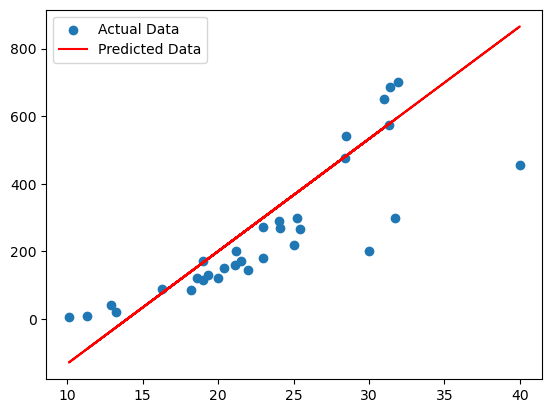

In [22]:
plt.scatter(x_test,y_test,label='Actual Data')
plt.plot(x_test,y_pred,label='Predicted Data',color = 'red')
plt.legend()

In [23]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [24]:
mean_squared_error(y_test,y_pred)

16917.312221946187

In [25]:
mean_absolute_error(y_test,y_pred)


93.87412129033645

In [26]:
r2_score(y_test,y_pred)

0.558839021555892

In [28]:
x_test = [[25]]

In [29]:
# y = mx  + b



In [30]:
y_new_pred = model.coef_*x_test + model.intercept_

In [32]:
y_new_pred

array([[366.65603321]])

In [36]:
y_new1_pred = model.predict(x_test)
y_new1_pred

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[366.65603321]])

In [37]:
# test size = 0.1,0.2,0.3,0.4,0.5


In [81]:
test_size = [0.1,0.2,0.3,0.4,0.5]
mse_value = []
r2_value = []
for i in test_size:
    x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=i,random_state=10)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    mse= mean_squared_error(y_test,y_pred)
    r2 = r2_score(y_test,y_pred)
    mse_value.append( mse)
    r2_value.append(r2)
    # print(i,mse)
    # print(i,r2)
    # print('_______________________')
print(mse_value)
print(f"Test Size : {test_size[mse_value.index(min(mse_value))]}, Min MSE: {min(mse_value)}")
print()
print('------------------------------------------------------------------------------------')
print()
print(r2_value)
print(f"Test Size : {test_size[r2_value.index(max(r2_value))]}, MAx MSE: {max(r2_value)}")


# print("Min MSE: ",min(mse_array))
# print("Min R2: ",min(r2_array))
# print("Max MSE: ",max(mse_array))
# print("Max R2: ",max(r2_array))
    

[15523.565250616111, 16917.312221946187, 21829.068497661665, 21568.924440960644, 20564.277656171947]
Test Size : 0.1, Min MSE: 15523.565250616111

------------------------------------------------------------------------------------

[0.617883675271323, 0.558839021555892, 0.7065203708440448, 0.7087432274790084, 0.7474337483186893]
Test Size : 0.5, MAx MSE: 0.7474337483186893


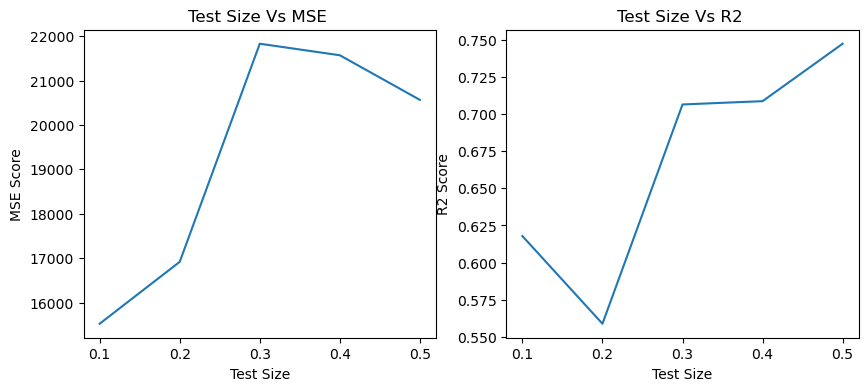

In [91]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title('Test Size Vs MSE ')
plt.plot(test_size,mse_value)
plt.xlabel('Test Size')
plt.ylabel("MSE Score")

plt.subplot(1,2,2)
plt.title('Test Size Vs R2 ')
plt.plot(test_size,r2_value)
plt.xlabel('Test Size')
plt.ylabel("R2 Score")

plt.show()

In [114]:
df.columns

Index(['Weight', 'Length1', 'Length2', 'Length3', 'Height', 'Width'], dtype='object')

In [115]:
x = df.drop('Weight',axis=1)

In [116]:
y = df[['Weight']]

In [117]:
df.corr(numeric_only=True)

,Weight,Length1,Length2,Length3,Height,Width
Weight,1.000000,0.915712,0.918618,0.923044,0.724345,0.886507
Length1,0.915712,1.000000,0.999517,0.992031,0.625378,0.867050
Length2,0.918618,0.999517,1.000000,0.994103,0.640441,0.873547
Length3,0.923044,0.992031,0.994103,1.000000,0.703409,0.878520
Height,0.724345,0.625378,0.640441,0.703409,1.000000,0.792881
Width,0.886507,0.867050,0.873547,0.878520,0.792881,1.000000


In [118]:
import seaborn as sns

<Axes: >

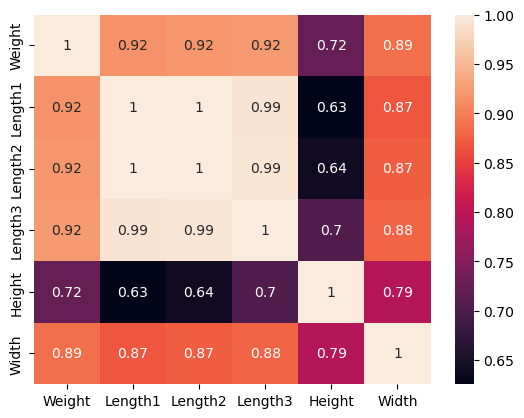

In [119]:
sns.heatmap(df.corr(),annot=True)

In [122]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=20)

In [124]:
print(x_test.shape,x_train.shape,y_train.shape,y_test.shape)


(32, 5) (127, 5) (127, 1) (32, 1)


In [126]:
model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred = model.predict(x_test)

In [129]:
Length1 :12.5
Length2	:23.6
Length3	:15.7
Height	:11.7
Width   :5.8